# Bartlett (Delay-and-sum) and Capon Beamforming in Multi-Target Scenario
We established everything we need to know about the signal model for DoA estimation problem in the previous notebook. In this one, we will start working on the problem.

This notebook will explain Bartlett and Capon together since they are interrelated.

In [1]:
# Importing modules
import numpy as np;
import matplotlib.pyplot as plt;

## Signal Model Refresher

* Antenna position matrix $\mathbf{P} \in \mathbb{R}^{3 \times N}$ holds the values for the position of the $n^{th}$ antenna element with respect to the origin point in meters.

$$
\mathbf{p}_{n} = [p_{n,x} \hat{\mathbf{x}}, p_{n,y} \hat{\mathbf{y}}, p_{n,z} \hat{\mathbf{z}}]^{T} \in \mathbb{R}^{3 \times 1}
\\
\mathbf{P} = [\mathbf{p}_{1}, ..., \mathbf{p}_{N}] \in \mathbb{R}^{3 \times N}
$$

* Target angle vector $\mathbf{\omega}_{k} \in \mathbb{R}^{3 \times 1}$ is the 3D Cartesian coordinate expression of the $k^{th}$ target's azimuth ($\phi_k$) and elevation ($\theta_k$) angles.

$$
\mathbf{\omega}_{k} = [sin(\theta_k)cos(\phi_k), sin(\theta_k)sin(\phi_k), cos(\phi_k)]^T \in \mathbb{R}^{3 \times 1}
$$

* Antenna steering vector $\mathbf{a}(\mathbf{\omega}_{k})$ encodes the phase shift for the $k^{th}$ target occuring at each antenna element.

$$
\mathbf{a}(\mathbf{\omega}_{k}) = \left[ e^{j {\mathbf{p}_{1}}^T \mathbf{\omega}_{k}}, \dots, e^{j {\mathbf{p}_{N}}^T \mathbf{\omega}_{k}} \right]^{T}
\\
\mathbf{A} = \left[\mathbf{a}(\mathbf{\omega}_1), \dots, \mathbf{a}(\mathbf{\omega}_K) \right] \in \mathbb{C} ^ {N \times K}
$$

In [2]:
# Defining methods
def steering_vector(
    sensor_pos: np.ndarray,
    ang_elev: float,
    ang_azim: float,
    wavelen: float
    ) -> np.ndarray:
  omega = np.array([[np.sin(ang_elev)*np.cos(ang_azim)],
                    [np.sin(ang_elev)*np.sin(ang_azim)],
                    [np.cos(ang_elev)]]); 
  return np.exp(1j*2*np.pi/wavelen*sensor_pos.T@omega); 


def generate_pos_1d_ula(
    N: int,
    d: float,
    axis=(1.,0.,0.),
    x_init=(0.,0.,0.)
    ) -> np.ndarray:
  if len(axis) != 3:
    raise TypeError(f"""The axis argument represents a 3D Cartesian vector.
      The length of the input ({len(axis)}) does not match with expected
      size 3."""); 
  if sum(axis) != 1:
    axis_new = (x/sum(axis) for x in axis);
    axis = axis_new; 

  if len(x_init) != 3:
    raise TypeError(f"""The x_init argument represents a 3D cartesian vector.
      The length of the input ({len(x_init)}) does not match with expected
      size 3."""); 

  sensor_pos = np.tile(x_init, N).reshape(N,3).T \
    + (np.arange(0,N,1)*d) * np.tile(np.array(axis), N).reshape(N,3).T; 
  return sensor_pos; 

hermitian = lambda array: np.conj(array).T; 

## Parameters
* $c$: Speed of light. In this example, assumed to be rounded to $30*10^8\text{ m/s}$.
* $f$: Frequency of the target signals in Herz. For this example, we will use $5\text{ GHz}$
* $\lambda$: Wavelength of the target signals in meters. It is calculated by the classical formula: $\lambda = \frac{c}{f}$, which gives $6\text{ cm}$ in our case.

Next step is to determine the ULA parameters.

* $N$: # of antenna elements. We can choose this value as $16$.
* $T$: # of snapshots. Let's be graceful to ourselves for now and choose an ample amount of samples, like 10000.
* $K$: # of targets. For an easy case, let's keep the number of targets at $3$.

In [3]:
# Defining parameters
c = 3*1e8;      # The speed of light in vacuum (m/s)
f = 5*1e9;      # Narrowband signal frequency (Hz)
wl = c/f;       # Signal wavelenght (m)
d = wl/2;       # Antenna distance (m)

N = 16;         # Number of antennas
T = 10000;      # Number of snapshots
K = 3;          # Number of targets

S_db = [0]*K;   # Target signal power (dB)
snr_db = 10.0;  # Signal-to-Noise Ratio (dB)

ang_azim = 0;   # Azimuth angle (deg)
ang_min = -60;  # Minimum elevation angle (deg)
ang_max = 60;   # Maximum elevation angle (deg)
ang_dist = 5;   # Minimum distance between targets (deg)
ang_res = 0.1   # Angular resolution in scanning (deg)

sensor_pos = generate_pos_1d_ula(N, d);               # Sensor position
theta_scan = np.arange(-90,90+ang_res,ang_res);       # Angle scan vector

For this example (and throughout the upcoming notebooks) target angles are generated randomly. While many test cases usually demonstrate the algorithms with a fixed target scenario, we decided to proceed with randomized targets for two essential reasons;

* The best way to demonstrate that these algorithms do, in fact, work is to run them with data generated by random, undetermined targets. Otherwise, what is the point of DoA estimation if we already know the angles?
* It is just as easy for a person to define their fixed target scenario as to define a simple NumPy array with hand-written target angle values.

Don't get me wrong, fixed-target scenarios are definitely useful in many cases, and we will eventually include them whenever we need for a particular analysis. Other than that, especially when we first discuss the DoA algorithms, we will just stick to generating our targets from the Uniform distribution. The minimum and maximum angle values used in this notebook by default will be $-60°$ and $60°$ respectively.

$$\theta_{k} \sim \mathbb{U}(\text{ang}_{min},\text{ang}_{max})$$

In [4]:
# Target Angle Generation
while True:
  true_angles = np.random.uniform(ang_min, ang_max, K); 
  angles_sort = np.sort(true_angles); 
  for i in range(K-1): # break for if is not valid
    is_valid = np.abs(angles_sort[i+1] - angles_sort[i]) >= ang_dist; 
    if not is_valid:
      break; 
  if is_valid: break; # break while if is valid

for k in range(K):
  print(f"Target {k} True Angle: {true_angles[k]:.2f}°"); 

Target 0 True Angle: 58.50°
Target 1 True Angle: 26.84°
Target 2 True Angle: 45.26°


## Covariance Matrix
If you have a solid background in statistical signal processing, you will realize how useful the property of *correlation* is in determining the presense of a signal of interest in a given data. You can be sure that we will use this property a lot.

The (true) *covariance matrix* $\mathbf{R}_{xx}$ is defined as the expected value of the autocorrelation of the multidimensional data. It will naturally have the dimensions of $N \times N$.

$$
\mathbf{R}_{xx} = E[\mathbf{X}\mathbf{X}^H] \in \mathbb{C}^{N \times N}
$$

$$
\mathbf{R}_{xx} = \mathbf{R}_{s} + \sigma_{n}^2 \mathbf{I}_n
$$

Since we don't have the characteristics of the incoming signal to calculate the covariance matrix, we will employ using a proxy called the *sample covariance matrix* $\hat{\mathbf{R}}_{xx}$, which is basically the approximation of $\mathbf{R}_{xx}$ by averaging out the sum of covariance matrices calculated with each individual scan.

$$
\hat{\mathbf{R}}_{xx} = \frac{1}{T} \sum_{t=1}^{T} \mathbf{x}(t)\mathbf{x}^H(t)
$$

In [5]:
A = np.column_stack([steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl) for theta in true_angles]); # Array Steering Matrix

# Target Signals: Uncorrelated complex Gaussian (Rayleigh fading)
S = (np.random.randn(K, T) + 1j*np.random.randn(K, T))/np.sqrt(2); 

# Noise: Spatially white complex Gaussian noise (thermal model)
noise_pow = np.sqrt(10**(-snr_db/10)); 
Noise = noise_pow * (np.random.randn(N, T) + 1j*np.random.randn(N, T))/np.sqrt(2); 

# Received Signal at the Array
X = A @ S + Noise; 

# Calculation of the sample covariance and its inverse (it will be used in Capon method)
Rxx_samp = (X @ hermitian(X))/T; 
Rxx_inv = np.linalg.inv(Rxx_samp); 

# Calculation of the true covariance matrix for comparison
Rxx_t = (A @ S @ hermitian(A @ S) + noise_pow * np.identity(N))/T; 

RMSE between Sample Covariance and True Covariance: 0.0272


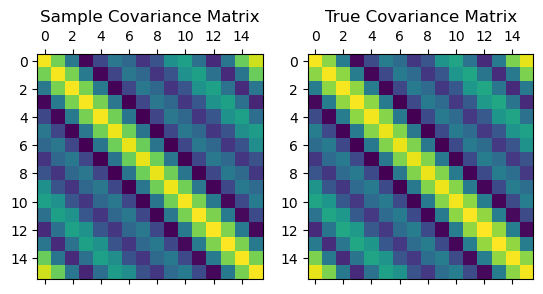

In [6]:
fig, (ax1, ax2) = plt.subplots(1,2); 
fig.figsize=(3,3); 
ax1.matshow(np.abs(Rxx_samp)); 
ax1.set_title("Sample Covariance Matrix"); 
ax2.matshow(np.abs(Rxx_t)); 
ax2.set_title("True Covariance Matrix"); 

print(f"RMSE between Sample Covariance and True Covariance: {np.sqrt(np.mean(np.square(np.abs(Rxx_samp - Rxx_t)))):.4f}"); 

The figures above show the sample (estimated) covariance matrix  $\hat{\mathbf{R}}_{xx}$ and the true (expected) covariance matrix $\mathbf{R}_{xx}$ for the particular data we created side-by-side. Without getting into any details, you can observe that our sample covariance matrix actually approximates the true covariance matrix very well. This is due to the huge number of snapshots we have at hand; thanks to the law of large numbers our approximation closely follows the statistical properties of the signal. This will not always be the case, so stay tuned for future discussions.

The next observation you can make is the dominance of the diagonal entries. This is also an expected result if we think of the data model we have: antenna readings have heavily fluctiating power in time and each follow and independent Normal distribution. Since non-diagonal entries of $\mathbf{R}_{xx}$ correspond to correlation between different antenna elements, they will naturally average out to zero as we add more snapshots.

There are a lot of other useful properties you can see; like the full Hermitian and Toeplitz structure. If you want to learn more, check out the paper *Compressive Covariance Sensing* by Daniel Romero and Geert Leus [here](https://ieeexplore.ieee.org/abstract/document/7366713?casa_token=Jej81pgbgIYAAAAA:YGeR0xATbZ2CRwVP3k0wf7IxDFKMcjqCMnOgK-0XUZ2f24XKKNKzXTnUza9BpY4AO9CyNWKt_g).

Now, as we established the

## The Bartlett Beamformer

Also known as the conventional *Delay-and-Sum* (DAS), it is the brute-force method for estimating the arrival angle by reconstructing the antenna response pattern. Essentially, it tests the array response for a given grid, and assumes the presense of a target at peak points of the spectrum.

The so-called *array response* function for a received signal $x(t)$ at time $t$ for a given angle $\theta$ is calculated as:

$$
ARF(\theta, t) = \mathbf{a}^H(\theta)\mathbf{x}(t)$$

Calculating the power of this wector will give us the pseudospectrum value for angle $\theta$:

$$
\begin{aligned}
P_{ARF}(\theta, t) &= (\mathbf{a}^H(\theta)\mathbf{x}(t))(\mathbf{a}^H(\theta)\mathbf{x}(t))^H
\\
&= \mathbf{a}^H(\theta)\mathbf{x}(t)\mathbf{x}^H(t)\mathbf{a}(\theta)
\end{aligned}
$$

Intuitively, the array response scan calculates the correlation values (think of it as applying matched filtering) on a given range of arrival angle values. When the inherent phase delay of the received signal highly correlates for a given scan angle there will be constructive addition, resulting in a high response value.

As the phase difference increases, we will start observing significant drops in array response. This should be no surprise; since phase difference relates to the trigonometric orthogonality between sine and cosine waves; one is just $90°$ phase-shifted version of the other!

We can play further with this form to get a neat, closed form solution. Let's start by averaging out the array response in time;

$$
\begin{aligned}
P_{ARF}(\theta) &= \frac{1}{T} \sum_{t=1}^{T} \mathbf{a}^H(\theta)\mathbf{x}(t)\mathbf{x}^H(t)\mathbf{a}(\theta)
\\
&= \mathbf{a}^H(\theta) \frac{1}{T}(\sum_{t=1}^{T}\mathbf{x}(t)\mathbf{x}^H(t)) \mathbf{a}(\theta)
\end{aligned}
$$

If you pay attention to the middle part of the right-hand side; you can actually figure out that it corresponds to our equation for the sample covariance matrix.

$$
P_{ARF}(\theta) = \mathbf{a}^H(\theta) \hat{\mathbf{R}}_{xx} \mathbf{a}(\theta)
$$`

The little code snipped below shows how stupendously simple the implementation of Bartlett is once you are equipped with all the background of the very nature of the problem.

In [7]:
P_bartlett = np.zeros(len(theta_scan), dtype=np.complex128); 

for i, theta in enumerate(theta_scan):
  bartlett = steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl); 
  P_bartlett[i] = np.squeeze(hermitian(bartlett) @ Rxx_samp @ bartlett); 

P_bartlett_db = 10*np.log10(np.abs(np.multiply(P_bartlett/np.amax(P_bartlett), np.conjugate(P_bartlett/np.amax(P_bartlett))))); 

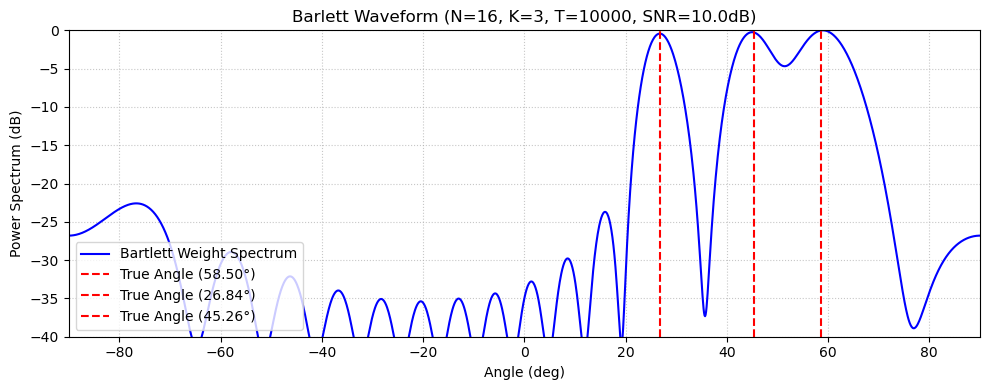

In [8]:
# Visualization of Bartlett
plt.rcParams.update({'font.size': 10}); 

plt.figure(figsize=(10,4)); 
plt.plot(theta_scan, P_bartlett_db, color='blue', label='Bartlett Weight Spectrum'); 

for i, angle in enumerate(true_angles):
    plt.axvline(x=angle, color='red', linestyle='--',
                label=f'True Angle ({angle:.2f}°)'); 

plt.title(f'Barlett Waveform (N={N}, K={K}, T={T}, SNR={snr_db}dB)'); 
plt.xlim([-90, 90]); plt.ylim([-40, 0]); 
plt.xlabel("Angle (deg)"); 
plt.ylabel("Power Spectrum (dB)"); 
plt.grid(True, linestyle=':', alpha=0.7); 

handles, labels = plt.gca().get_legend_handles_labels(); 
by_label = dict(zip(labels, handles)); 
plt.legend(by_label.values(), by_label.keys(), loc="lower left"); 

plt.tight_layout(); 
plt.show(); 

When you run the code above to see how Bartlett performed, you may first be surprised that such a basic setup worked well even with our assumption of complete independent randomness for the incoming signal power. That is the beauty of the array processing; the target arrival information is essentially encoded right at the arrival by the structural phase shift of the antenna array. Bartlett exploits this information by using the orthogonality of the trigonometric functions.

So, what problems do we have with Bartlett beamforming?
* First of all, if you come across a dataset with targets that are close enough (you may run the notebook a couple of times to get such case, or just put your own values to see), you may observe that the spectrum between the targets has a very strong power level. This is unfortunately expected to happen due to the superposition of the semi-constructive coupling between very close phase differences.
* A second problem is the generalization of this phenomenon for all targets: that is, Bartlett beamforming has quite large main lobe around the target angles. Phase differences around actual targets are in fact not as large to completely be coupled with the scan array destructively. The average resolution for Bartlett beamforming is $\lambda / D$ for the wavelength $\lambda$ and the array aperture size $D$.

In [9]:
theta_scan_360 = np.arange(-180,180+ang_res,ang_res); 
P_bartlett_360 = np.zeros(len(theta_scan_360), dtype=np.complex128); 

for i, theta in enumerate(theta_scan_360):
  bartlett = steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl); 
  P_bartlett_360[i] = np.squeeze(hermitian(bartlett) @ Rxx_samp @ bartlett); 

P_bartlett_360_db = 10*np.log10(np.abs(np.multiply(P_bartlett_360/np.amax(P_bartlett_360), np.conjugate(P_bartlett_360/np.amax(P_bartlett_360))))); 

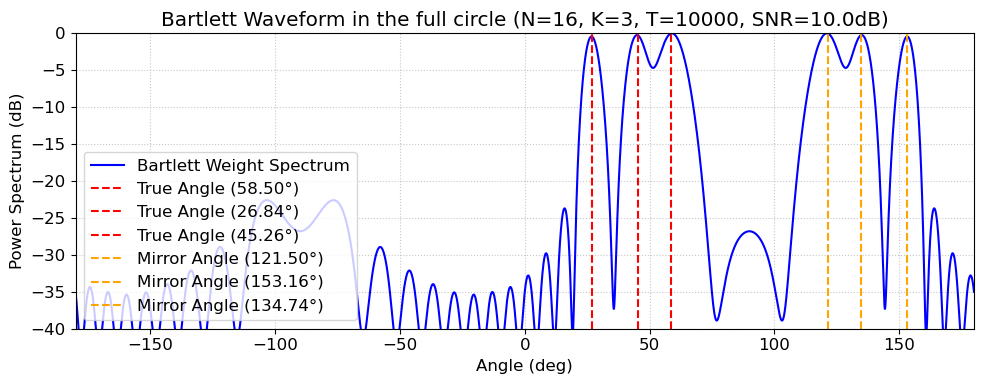

In [10]:
# Visualization of Bartlett on a 360-degree scan
plt.rcParams.update({'font.size': 12}); 

plt.figure(figsize=(10,4)); 
plt.plot(theta_scan_360, P_bartlett_360_db, color='blue', label='Bartlett Weight Spectrum'); 

for i, angle in enumerate(true_angles):
    plt.axvline(x=angle, color='red', linestyle='--',
                label=f'True Angle ({angle:.2f}°)'); 

for i, angle in enumerate(true_angles):
    plt.axvline(x=np.sign(angle)*(180-abs(angle)), color='orange', linestyle='--',
                label=f'Mirror Angle ({np.sign(angle)*(180-abs(angle)):.2f}°)'); 

plt.title(f'Bartlett Waveform in the full circle (N={N}, K={K}, T={T}, SNR={snr_db}dB)'); 
plt.xlim([-180, 180]); plt.ylim([-40, 0]); 
plt.xlabel("Angle (deg)"); 
plt.ylabel("Power Spectrum (dB)"); 
plt.grid(True, linestyle=':', alpha=0.7); 

handles, labels = plt.gca().get_legend_handles_labels(); 
by_label = dict(zip(labels, handles)); 
plt.legend(by_label.values(), by_label.keys(), loc="lower left"); 

plt.tight_layout(); 
plt.show(); 

Is this graph kind of confusing? It may very well be. We can take a look at a different form of graph in order to make it more intuitive. In the next code snippet you will find the drawing of the array response, this time on a *polar graph* that is commonly used in antenna design.

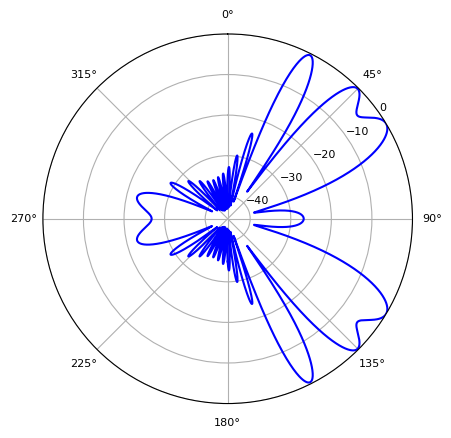

In [11]:
plt.rcParams.update({'font.size': 8}); 

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}); 
fig.figsize=(4,4); 
ax.plot(np.deg2rad(theta_scan_360), P_bartlett_360_db, color='blue'); 
ax.set_theta_zero_location('N'); 
ax.set_theta_direction(-1); 
ax.set_rlabel_position(55); 

plt.show(); 

Polar graphs are awesome for visualizing antenna gain and beam patterns in an intuitive manner. The one you see here is the relative power across array scan, therefore it informs us on how much power we actually receive once we scan through the whole circle. Here, you can clearly see that we have duplicates of our targets on the opposite side of the antenna array. If you think a little bit about the array structure we use, this actually makes sense: ULAs are laid across a particular line, the phase shifts on the opposite side will have the conjugate power response. Since we aren't interested in the opposite side of the angle ($-90°$ to $90°$ counter-clockwise) you may think that what the point is for discussing it.

Well, remember that Bartlett method is susceptible to close targets due to its large beamwidth across target positions. This phenomenon includes virtual targets happening behind the look angle. When targets are very close to the edge of the range of interest, the virtual targets will distort the estimation. While the mirroring is not unique to Bartlett beamformers, the lack of compensation for this effect makes Bartlett not an ideal method to deal with it.

We can finally take a step back and take a different look at the system; not as a scan array search, but as a problem of optimization for a given set of parameters $\mathbf{w}$. In this regard, Bartlett beamforming becomes a simple search of the optimum weights within a predefined set of weight vectors that maximizes the power gain.  

$$
P_{ARF}(\theta) = \mathbf{w}_{Bartlett} \hat{\mathbf{R}}_{xx} \mathbf{w}_{Bartlett}
$$

$$
\mathbf{w}_{Bartlett} = \mathbf{a}(\theta)
$$

This is an important observation, because it shows us the issues with Bartlett. While it is a useful and cheap beamforming method for known directions, it becomes extremely tedious when dealing with the DoA problem since we have to repeat this process for each data we pick. We are also constrained in both respects; the search grid resolution determines the accuracy of our DoA estimation, and the only available weights in the set are the simple phase delay vectors.

## Capon Beamforming
The Capon beamforming, also known as the *Minimum Variance Distortionless Response* (MVDR) is an extension over the DAS beamforming that primarily targets the sidelobe issue with the DAS beamformer. It was developed by J. Capon in 1960.

The goal of Capon beamforming is to minimize the total output power of the array (i.e., the variance in the spectrum function, thus the "Minimum Variance" part of the name) while maintaining a distortionless response (a gain of exactly 1, and giving the "Distortionless Response" part of the name) in the scan direction $\theta$. Capon manages this first through defining a complex weight vector $\mathbf{w} \in \mathbb{C}^N$ to control the gains of the antenna elements.

* Objective Function: Minimize the output power, $P(\mathbf{w}) = \mathbf{w}^H \mathbf{R}_{xx} \mathbf{w}$
* Constraint: $\mathbf{w}^H \mathbf{a}(\theta) = 1$

$$
\begin{aligned}
\min_{\mathbb{w}} &\quad \mathbf{w}^H \mathbf{R}_{xx} \mathbf{w}
\\
\text{subject to} &\quad \mathbf{w}^H \mathbf{a}(\theta) = 1
\end{aligned}
$$

### Derivation

The objective function and the constraint is first combined into a single Lagrangian function, $L(\mathbf{w}, \lambda)$, with the [*Lagrange multiplier*](https://en.wikipedia.org/wiki/Lagrange_multiplier) $\lambda$.

$$L(\mathbf{w}, \lambda) = \mathbf{w}^H \mathbf{R}_{xx} \mathbf{w} + \lambda (\mathbf{w}^H \mathbf{a} - 1)$$

With a single look, we can assess that the Lagrangian form of the problem is convex; it is a basic vector polynomial with respect to $\mathbf{w}$. The next step is, then, to calculate the Lagrangian function's gradient with respect to $\mathbf{w}$ to find the minimum point. Because $\mathbf{w}$ is a complex vector, we utilize [*Wirtinger calculus*](https://en.wikipedia.org/wiki/Wirtinger_derivatives), which allows us to treat $\mathbf{w}$ and its conjugate $\mathbf{w}^H$ as independent variables.

We take the partial derivative of $L$ with respect to the conjugate vector $\mathbf{w}^H$ and set it to the zero vector ($\mathbf{0}$):

$$\frac{\partial L(\mathbf{w}, \lambda)}{\partial \mathbf{w}^H} = \mathbf{R}_{xx} \mathbf{w} + \lambda \mathbf{a} = \mathbf{0}$$

Now, we algebraically rearrange the gradient equation to isolate $\mathbf{w}$ in terms of our unknown multiplier $\lambda$.

* Subtract $\lambda \mathbf{a}$ from both sides: $$\mathbf{R}_{xx}\mathbf{w} = -\lambda \mathbf{a}$$
* Multiply both sides by the inverse of the covariance matrix, $\mathbf{R}_{xx}^{-1}$ (assuming $\mathbf{R}_{xx}$ is full-rank and invertible, which it generally is in practice due to the presence of uncorrelated sensor noise): $$\mathbf{w} = -\lambda \mathbf{R}_{xx}^{-1} \mathbf{a}$$

At this stage, we have the optimal shape of the weight vector, but we still need to determine the exact scaling factor driven by the constant $-\lambda$. To find the value of $-\lambda$, we plug our expression for $\mathbf{w}$ back into our original distortionless constraint.

First, recall the constraint is $\mathbf{w}^H \mathbf{a} = 1$. Because the result is a real scalar, taking the Hermitian transpose of the entire constraint yields an equivalent and more convenient form:

$$(\mathbf{w}^H \mathbf{a})^H = 1^H \implies \mathbf{a}^H \mathbf{w} = 1$$

Now, we will substitute our expression for $\mathbf{w}$ into this constraint, factor out the scalar $-\lambda$, and finally isolate $-\lambda$:

$$
\begin{aligned}
\mathbf{a}^H (-\lambda \mathbf{R}_{xx}^{-1} \mathbf{a}) &= 1
\\
-\lambda (\mathbf{a}^H \mathbf{R}_{xx}^{-1} \mathbf{a}) &= 1
\\
-\lambda &= \frac{1}{\mathbf{a}^H \mathbf{R}_{xx}^{-1} \mathbf{a}}
\end{aligned}
$$

Finally, we substitute the solved value of $-\lambda$ back into our equation for the weight vector ($\mathbf{w} = -\lambda \mathbf{R}_{xx}^{-1} \mathbf{a}$).

$$\mathbf{w}_{Capon} = \left( \frac{1}{\mathbf{a}^H \mathbf{R}_{xx}^{-1} \mathbf{a}} \right) \mathbf{R}_{xx}^{-1} \mathbf{a}$$

Which cleans up to the final MVDR formula:

$$
\mathbf{w}_{Capon} = \frac{\mathbf{R}_{xx}^{-1} \mathbf{a}}{\mathbf{a}^H \mathbf{R}_{xx}^{-1} \mathbf{a}}
$$

The implementation of capon beamforming is no harder than the Bartlett; the final close-form format of the weights give us a brilliant and elegant extension over our previous loop.

In [12]:
P_capon = np.zeros(len(theta_scan), dtype=np.complex128); 

for i, theta in enumerate(theta_scan):
    fourier = steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl); 
    capon = (Rxx_inv @ fourier) / (hermitian(fourier) @ Rxx_inv @ fourier); 
    P_capon[i] = np.squeeze(hermitian(capon) @ Rxx_samp @ capon); 

P_capon_db = 10*np.log10(np.abs(np.multiply(P_capon/np.amax(P_capon), np.conjugate(P_capon/np.amax(P_capon))))); 

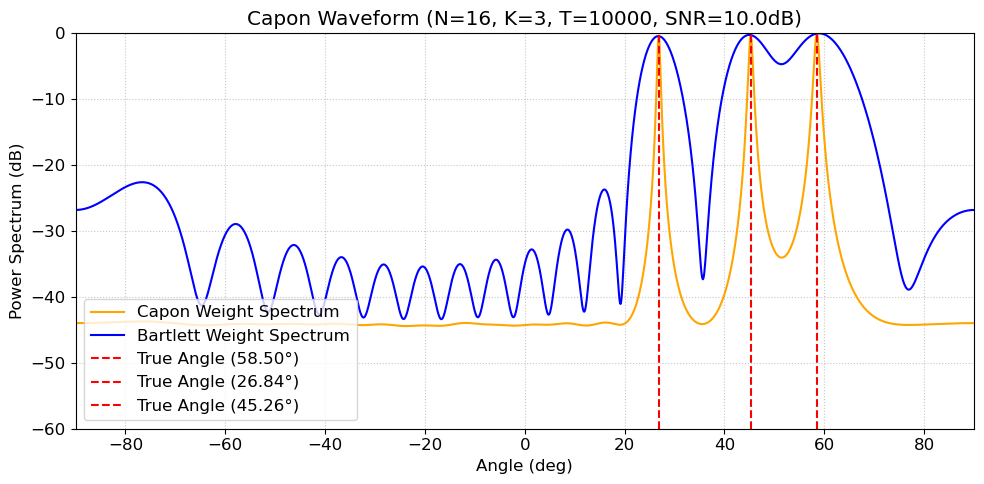

In [13]:
# Visualization
plt.rcParams.update({'font.size': 12}); 

plt.figure(figsize=(10,5)); 
plt.plot(theta_scan, P_capon_db, color='orange', label='Capon Weight Spectrum'); 
plt.plot(theta_scan, P_bartlett_db, color='blue', label='Bartlett Weight Spectrum'); 

for i, angle in enumerate(true_angles):
    plt.axvline(x=angle, color='red', linestyle='--',
                label=f'True Angle ({angle:.2f}°)'); 

plt.title(f'Capon Waveform (N={N}, K={K}, T={T}, SNR={snr_db}dB)'); 
plt.xlim([-90, 90]); plt.ylim([-60, 0]); 
plt.xlabel("Angle (deg)"); 
plt.ylabel("Power Spectrum (dB)"); 
plt.grid(True, linestyle=':', alpha=0.7); 

handles, labels = plt.gca().get_legend_handles_labels(); 
by_label = dict(zip(labels, handles)); 
plt.legend(by_label.values(), by_label.keys(), loc="lower left"); 

plt.tight_layout(); 
plt.show(); 

When you run Capon, you can see how sharp the peaks are compared to the Bartlett spectrum. The Capon weights were particularly constrained just for this across a much larger search space. Let's print the Capon Power spectrum on the polar coordinate.

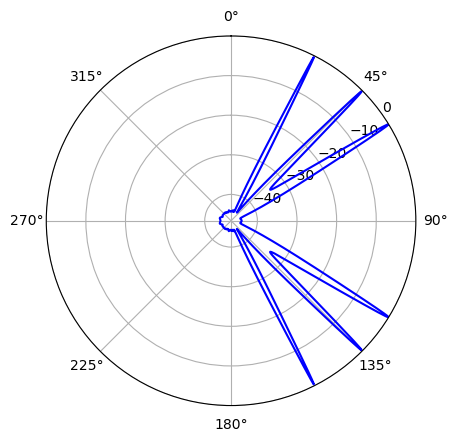

In [14]:
P_capon_360 = np.zeros(len(theta_scan_360), dtype=np.complex128); 

for i, theta in enumerate(theta_scan_360):
    fourier = steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl); 
    capon = (Rxx_inv @ fourier) / (hermitian(fourier) @ Rxx_inv @ fourier); 
    P_capon_360[i] = np.squeeze(hermitian(capon) @ Rxx_samp @ capon); 

P_capon_360_db = 10*np.log10(np.abs(np.multiply(P_capon_360/np.amax(P_capon_360), np.conjugate(P_capon_360/np.amax(P_capon_360))))); 

plt.rcParams.update({'font.size': 10}); 

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}); 
ax.plot(np.deg2rad(theta_scan_360), P_capon_360_db, color='blue'); 
ax.set_theta_zero_location('N'); 
ax.set_theta_direction(-1); 
ax.set_rlabel_position(55); 
plt.show(); 

Beautifully sharp responses!

Congratulations! You went through the very first and most essential DoA estimation method available in the literature! These two methods will be our unofficial benchmarks for other algorithm implementations.

## Resources

[Delay Sum Beamforming](http://www.labbookpages.co.uk/audio/beamforming/delaySum.html) by The Lab Book Pages.

[Beamforming & DOA](https://pysdr.org/content/doa.html) by PySDR.

[Smoothing Periodograms from Time-Series with Continuous Spectra](https://www.nature.com/articles/161686a0#preview). M.S. Bartlett. *Biometrika*. Volume 37, Issue 1-2. June 1950. Pages 1-16.

[Peiodogram Analysis and Continuous Spectra](https://academic.oup.com/biomet/article/37/1-2/1/194725?login=true). M.S. Bartlett. *Nature*. Volume 161. 01 May 1948.

[High-resolution frequency-wavenumber spectrum analysis](https://ieeexplore.ieee.org/abstract/document/1449208). J. Capon. *Proceedings of the IEEE*. Volume 57, Issue 8. August 1969.